<a href="https://colab.research.google.com/github/lokendradevv/Nike-vs-Adidas-Product-Segmentation-Using-Machine-Learning/blob/main/Nike_vs_AdidadProductSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Segmentation Case Study

## Context

When we think of sneakers for a trip, the importance of good footwear cannot be discarded, and the obvious brands that come to mind are Adidas and Nike. Adidas vs Nike is a constant debate as the two giants in the apparel market, with a large market cap and market share, battle it out to come on top. As a newly hired Data Scientist in a market research company, you have been given the task of extracting insights from the data of men's and women's shoes, and grouping products together to identify similarities and differences between the product range of these renowned brands.

## Objective

To perform an exploratory data analysis and cluster the products based on various factors


## Key Questions

- Which variables are most important for clustering?
- How each cluster is different from the others?
- What are the business recommendations?


## Data Description

The dataset consists of 3268 products from Nike and Adidas with features of information including their ratings, discount, sales price, listed price, product name, and the number of reviews.

- Product Name: Name of the product
- Product ID: ID of the product
- Listing Price: Listed price of the product
- Sale Price: Sale price of the product
- Discount: Percentage of discount on the product
- Brand: Brand of the product
- Rating: Rating of the product
- Reviews: Number of reviews for the product

### Importing necessary libraries

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [ ]:
from google.colab import drive

# Mount Google Drive to /content/drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading the dataset
data = pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/Unsupervised Learning/data_add_nik.csv")

In [ ]:
data.shape

(3268, 8)

* The dataset has 3268 rows and 8 columns

In [ ]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
255,Women's adidas Originals POD-S3.1 Shoes,CG6188,13999,6999,50,Adidas ORIGINALS,3.3,8
1551,Men's adidas Originals Superstar Pure Shoes,FV3013,11999,11999,0,Adidas ORIGINALS,3.9,10
1352,Men's adidas Originals Superstar Shoes,FV2806,7999,7999,0,Adidas ORIGINALS,4.4,42
1060,Men's adidas Football Nemeziz 19.3 Indoor Shoes,F34411,5999,3599,40,Adidas SPORT PERFORMANCE,4.5,75
808,Men's adidas Sport Inspired Court 80s Shoes,EE9676,5999,3599,40,Adidas CORE / NEO,4.5,55
836,Men's adidas Running Stargon 1.0 Shoes,CM4935,4799,3839,20,Adidas CORE / NEO,3.5,21
2107,Men's adidas Originals Yung-96 Chasm Shoes,EE7238,7999,4799,40,Adidas ORIGINALS,3.0,62
3002,Nike SB Air Max Stefan Janoski 2,AQ7477-009,0,9995,0,Nike,2.6,11
2329,Men's adidas Originals Rivalry Low Shoes,FV4287,10999,10999,0,Adidas ORIGINALS,2.8,8
602,Men's adidas Sport Inspired Lite Racer RBN Shoes,F36642,5599,3919,30,Adidas CORE / NEO,3.0,56


In [ ]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

In [ ]:
# fixing column names
df.columns = [c.replace(" ", "_") for c in df.columns]

In [ ]:
# let's look at the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_Name   3268 non-null   object 
 1   Product_ID     3268 non-null   object 
 2   Listing_Price  3268 non-null   int64  
 3   Sale_Price     3268 non-null   int64  
 4   Discount       3268 non-null   int64  
 5   Brand          3268 non-null   object 
 6   Rating         3268 non-null   float64
 7   Reviews        3268 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 204.4+ KB


**We won't need Product_ID for analysis, so let's drop this column.**

In [ ]:
df.drop("Product_ID", axis=1, inplace=True)

In [ ]:
# let's check for duplicate observations
df.duplicated().sum()

np.int64(117)

- There are 117 duplicate observations. We will remove them from the data.

In [ ]:
df = df[(~df.duplicated())].copy()

**Let's take a look at the summary of the data**

In [ ]:
df.describe()

,Listing_Price,Sale_Price,Discount,Rating,Reviews
count,3151.000000,3151.000000,3151.000000,3151.000000,3151.000000
mean,7045.960330,5983.166931,27.860997,3.285687,41.891146
std,4652.089511,4173.708897,22.442753,1.371611,31.283464
min,0.000000,449.000000,0.000000,0.000000,0.000000
25%,4599.000000,2999.000000,0.000000,2.600000,12.000000
50%,5999.000000,4599.000000,40.000000,3.600000,40.000000
75%,8999.000000,7799.000000,50.000000,4.400000,69.000000
max,29999.000000,36500.000000,60.000000,5.000000,223.000000


**Observations**

- 0 in the listing price indicates missing values.
- The average listing price is 7046.
- The average sale price is 5983.
- The average discount is 28%.
- The average rating is 3.3.
- The average number of reviews is 42.

In [ ]:
# let's check how many products have listing price 0
(df.Listing_Price == 0).sum()

np.int64(336)

In [ ]:
# let's check the products which have listing price 0
df[(df.Listing_Price == 0)]

,Product_Name,Listing_Price,Sale_Price,Discount,Brand,Rating,Reviews
2625,Nike Air Force 1 '07 Essential,0,7495,0,Nike,0.0,0
2626,Nike Air Force 1 '07,0,7495,0,Nike,0.0,0
2627,Nike Air Force 1 Sage Low LX,0,9995,0,Nike,0.0,0
2628,Nike Air Max Dia SE,0,9995,0,Nike,0.0,0
2629,Nike Air Max Verona,0,9995,0,Nike,0.0,0
...,...,...,...,...,...,...,...
3254,Nike Mercurial Vapor 13 Club MG,0,4995,0,Nike,0.0,0
3257,Air Jordan 5 Retro,0,15995,0,Nike,3.3,3
3260,Nike Tiempo Legend 8 Academy TF,0,6495,0,Nike,0.0,0
3262,Nike React Metcon AMP,0,13995,0,Nike,3.0,1


In [ ]:
df[(df.Listing_Price == 0)].describe()

,Listing_Price,Sale_Price,Discount,Rating,Reviews
count,336.0,336.000000,336.0,336.000000,336.000000
mean,0.0,11203.050595,0.0,2.797619,8.261905
std,0.0,4623.825788,0.0,2.150445,19.708393
min,0.0,1595.000000,0.0,0.000000,0.000000
25%,0.0,7995.000000,0.0,0.000000,0.000000
50%,0.0,10995.000000,0.0,3.950000,1.000000
75%,0.0,13995.000000,0.0,4.700000,6.000000
max,0.0,36500.000000,0.0,5.000000,223.000000


- There are 336 observations that have missing values in the listing price column
- We see that the discount for the products with listing price 0 is 0.
- So, we will replace the listing price with the corresponding sale price for those observations.

In [ ]:
df.loc[(df.Listing_Price == 0), ["Listing_Price"]] = df.loc[
    (df.Listing_Price == 0), ["Sale_Price"]
].values

In [ ]:
df.Listing_Price.describe()

,Listing_Price
count,3151.000000
mean,8240.573151
std,4363.018245
min,899.000000
25%,4999.000000
50%,7599.000000
75%,10995.000000
max,36500.000000


In [ ]:
# checking missing values
df.isna().sum()

,0
Product_Name,0
Listing_Price,0
Sale_Price,0
Discount,0
Brand,0
Rating,0
Reviews,0


- There are no missing values in the data.

## EDA

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

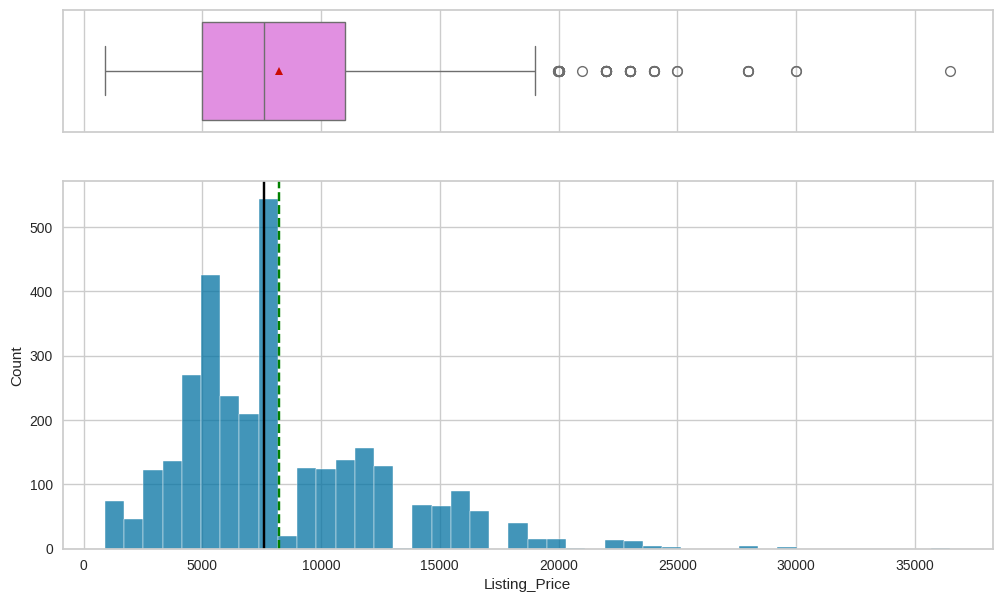

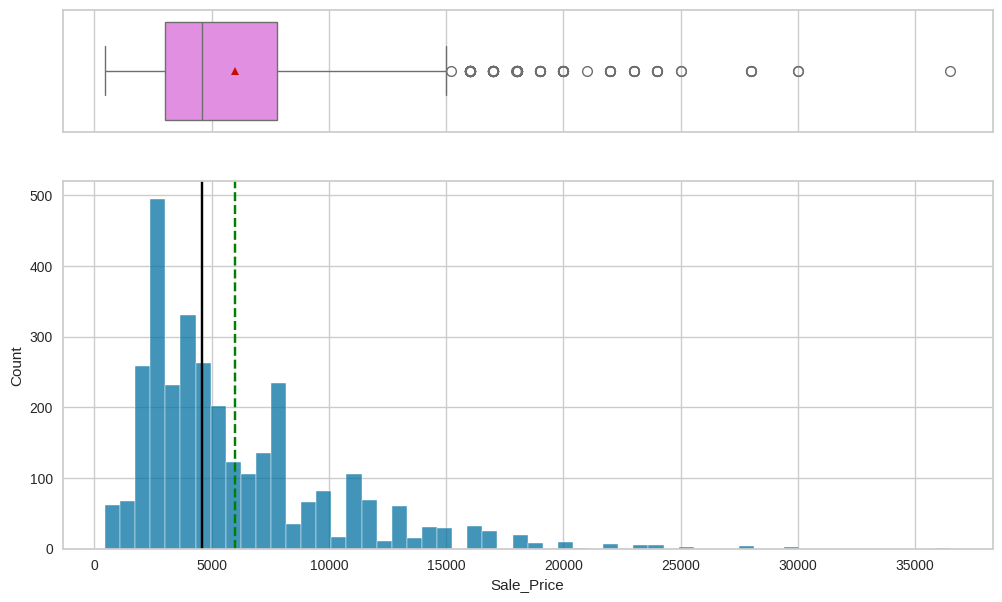

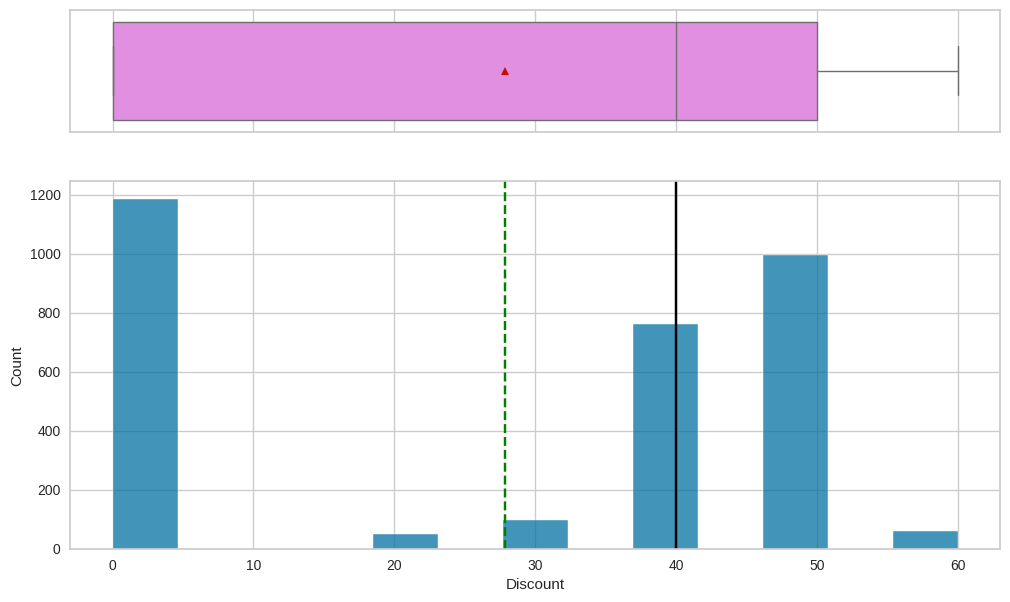

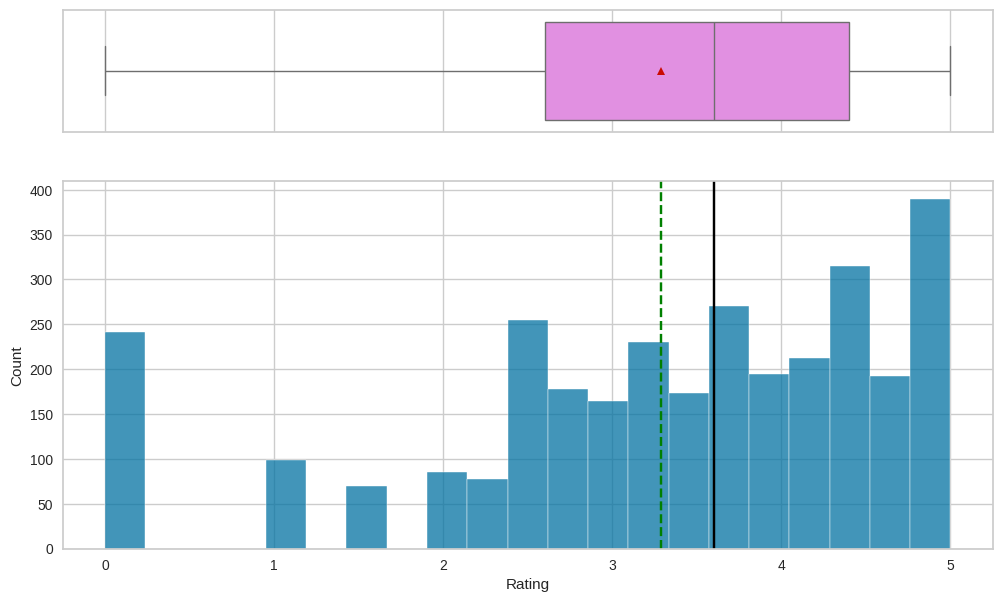

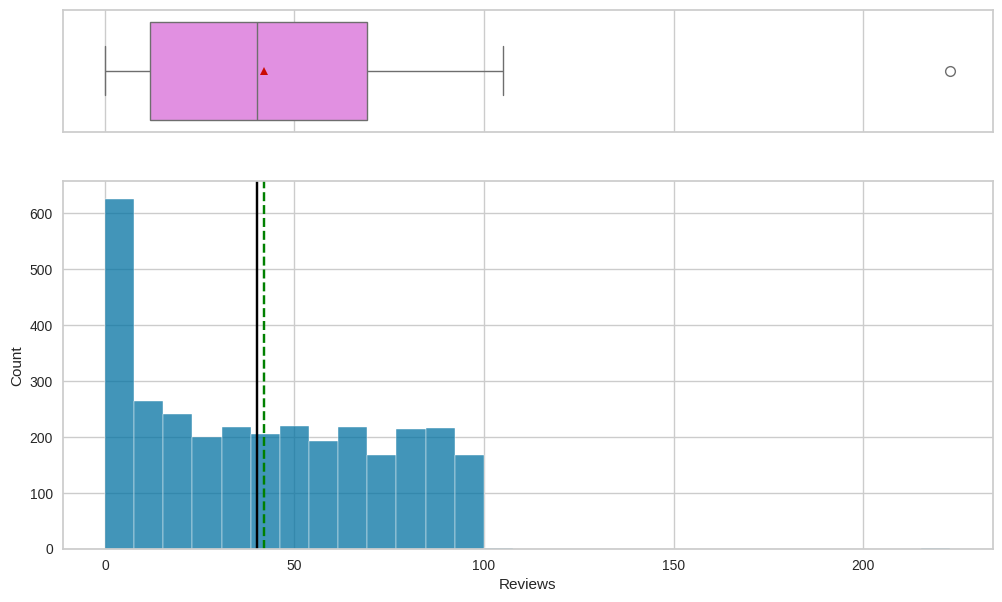

In [ ]:
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

**Observations**

- Listing price and sale price have right-skewed distributions with upper outliers, which indicates the presence of very expensive products.
- The maximum discount given is 60%.
- Rating is left-skewed and most of the ratings are between 2.5 and 4.5.
- The number of reviews is between 1 and 100, with an outlier value above 200.

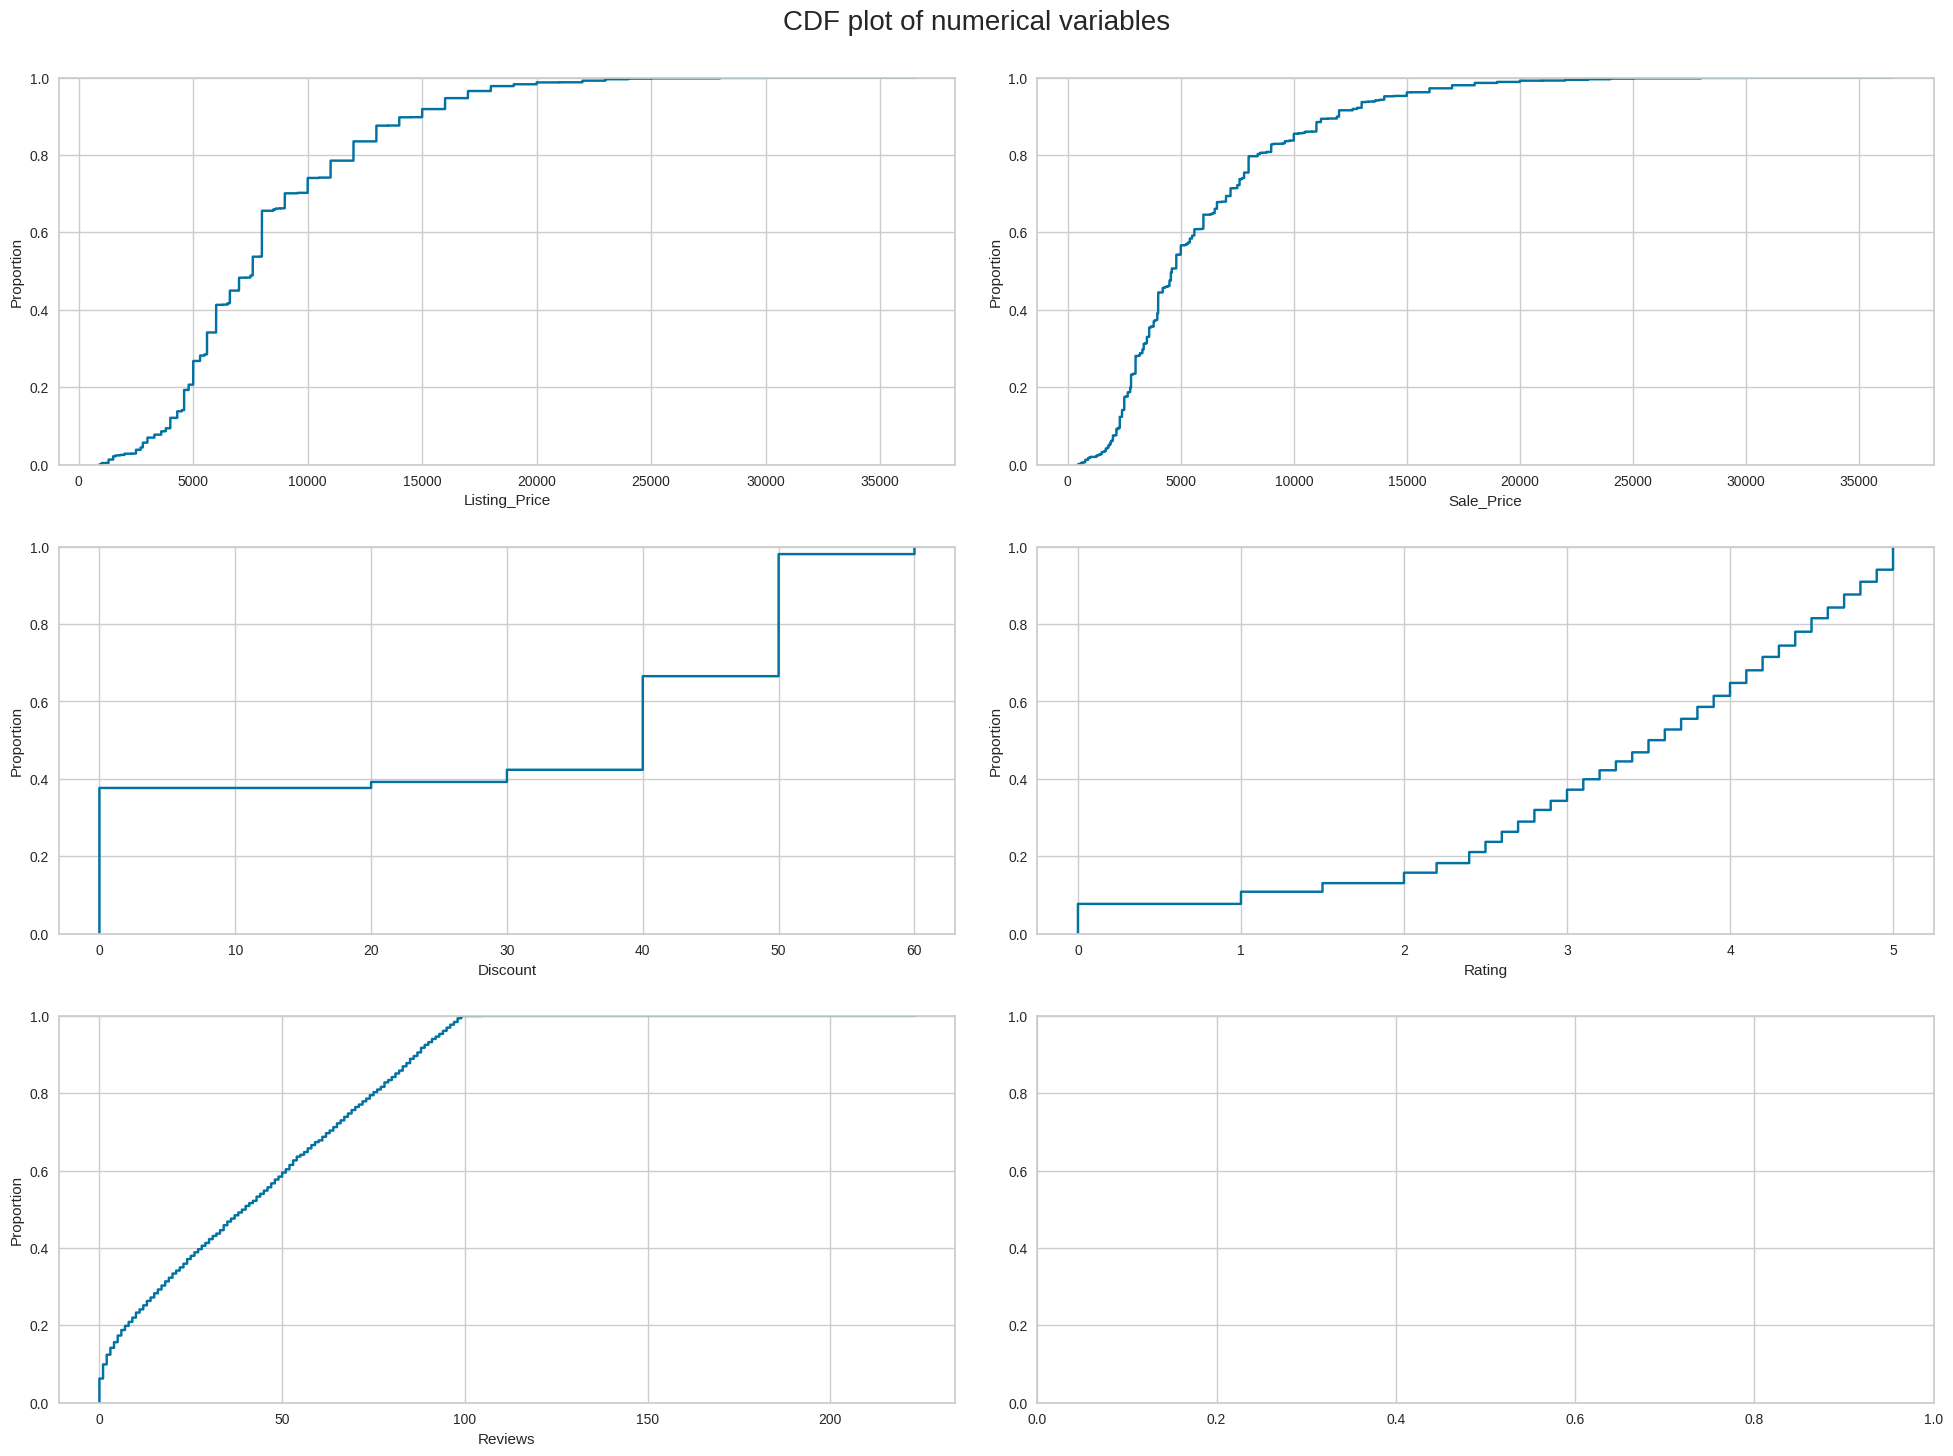

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle("CDF plot of numerical variables", fontsize=20)
counter = 0
for ii in range(3):
    sns.ecdfplot(ax=axes[ii][0], x=df[num_col[counter]])
    counter = counter + 1
    if counter != 5:
        sns.ecdfplot(ax=axes[ii][1], x=df[num_col[counter]])
        counter = counter + 1
    else:
        pass

fig.tight_layout(pad=2.0)

**Observations**

- 90% of the products have listing prices less than 15000.
- 95% of the product have a sale price of less than 15000.
- 80% of the products have at least 50% discount or less than 50%.
- 50% off the products have a rating of 3.5 or less than 3.5.
- Almost all products have 100 or fewer reviews.

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

/tmp/ipykernel_9907/1031480784.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


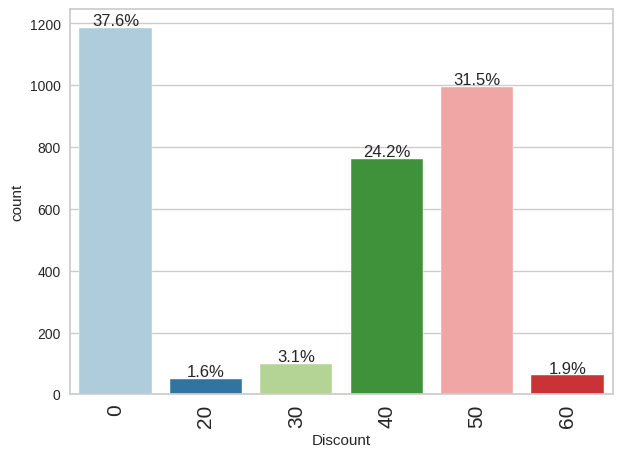

In [ ]:
# let's explore discounts further
labeled_barplot(df, "Discount", perc=True)

**Observations**

- 37.6% of products did not have any discounts.
- More than 50% of the products have 40-50% discount.

## Bivariate Analysis

**Let's check for correlations.**

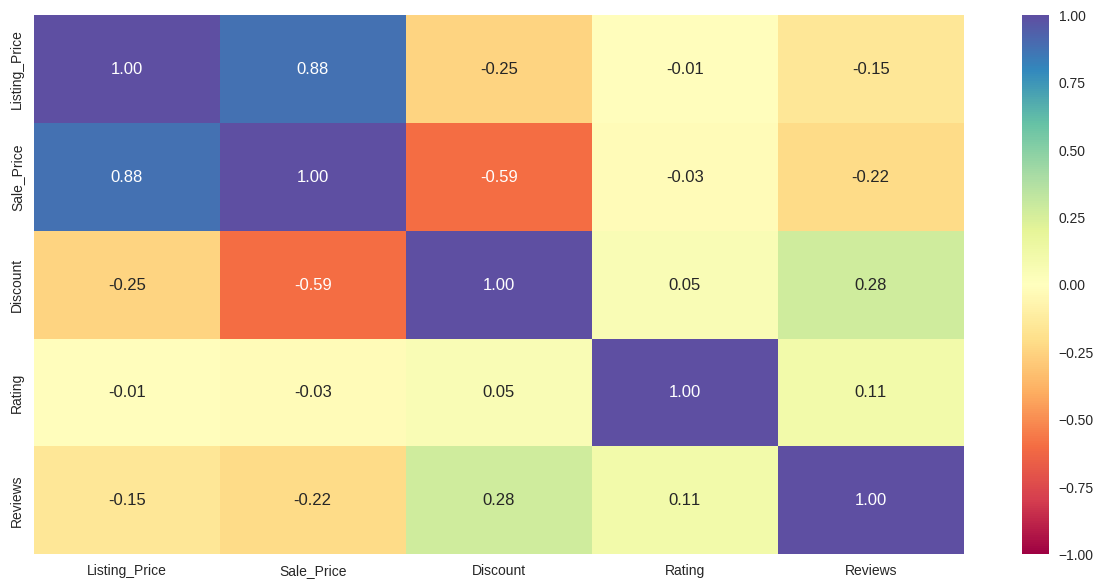

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations**

- The sale price and the listing price are highly positively correlated, which is obvious.
- Discount is somewhat negatively correlated with listing price or sale price, which indicates that expensive products either have fewer discounts or no discounts at all.

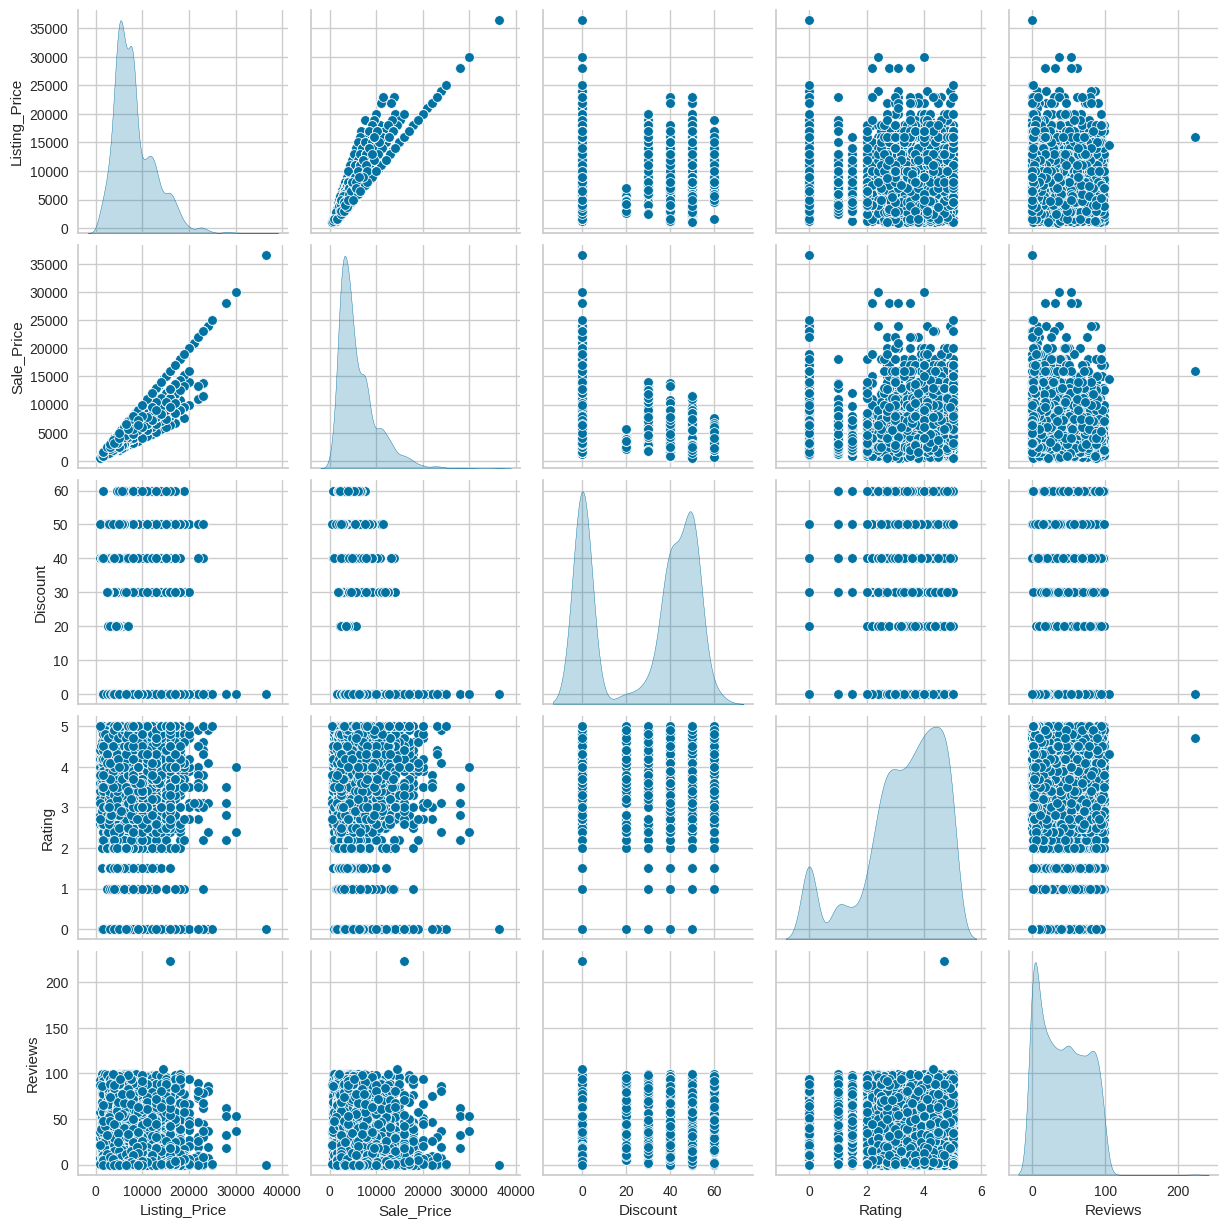

In [ ]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

**Observations**

- 50-60% discounts are mostly given to products whose listing price is 10,000 or less.
- Many products have no discount.
- As seen before, most of the products have 100 or fewer reviews.

## Data Preprocessing

In [ ]:
# variables used for clustering
num_col

['Listing_Price', 'Sale_Price', 'Discount', 'Rating', 'Reviews']

In [ ]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

## K-means Clustering

Number of Clusters: 1 	Average Distortion: 2.0907211006458253
Number of Clusters: 2 	Average Distortion: 1.7119292934572274
Number of Clusters: 3 	Average Distortion: 1.5700106679163794
Number of Clusters: 4 	Average Distortion: 1.4187210104303147
Number of Clusters: 5 	Average Distortion: 1.34155348222277
Number of Clusters: 6 	Average Distortion: 1.2304081945537575
Number of Clusters: 7 	Average Distortion: 1.1774240441154868
Number of Clusters: 8 	Average Distortion: 1.1008371131523094


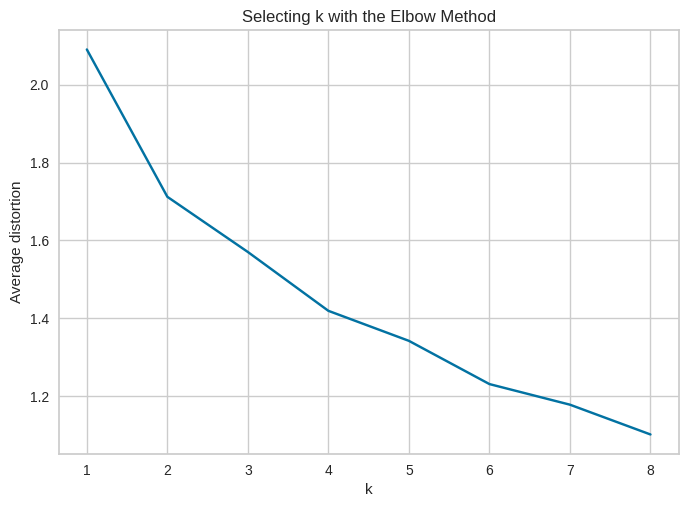

In [ ]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

**Appropriate value for k seems to be 3 or 4.**

**Let's check the silhouette scores.**

For n_clusters = 2, the silhouette score is 0.33462520494927556)
For n_clusters = 3, the silhouette score is 0.29598907020279747)
For n_clusters = 4, the silhouette score is 0.2655318767267271)
For n_clusters = 5, the silhouette score is 0.27039138539420854)
For n_clusters = 6, the silhouette score is 0.2654218731583294)
For n_clusters = 7, the silhouette score is 0.27918944669373275)
For n_clusters = 8, the silhouette score is 0.28314653043612303)
For n_clusters = 9, the silhouette score is 0.2871970816499864)


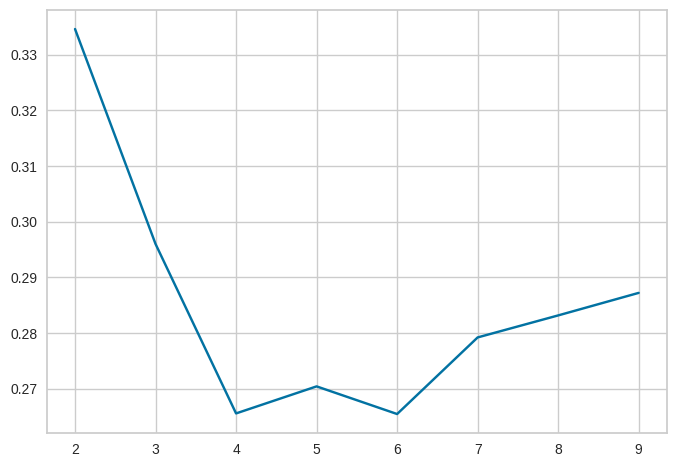

In [ ]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

Number of Clusters: 1, Distortion: 2.2078794904035717
Number of Clusters: 2, Distortion: 1.846057488285945
Silhouette Score for k=2: 0.3202081745362201
Number of Clusters: 3, Distortion: 1.5923876197756712
Silhouette Score for k=3: 0.36578134606622315
Number of Clusters: 4, Distortion: 1.446130430556019
Silhouette Score for k=4: 0.36974502646748536
Number of Clusters: 5, Distortion: 1.4149347305007374
Silhouette Score for k=5: 0.36165643497558486
Number of Clusters: 6, Distortion: 1.2798252404828079
Silhouette Score for k=6: 0.3006318958734603
Number of Clusters: 7, Distortion: 1.217093802534442
Silhouette Score for k=7: 0.2843382518816367
Number of Clusters: 8, Distortion: 1.1180620640813375
Silhouette Score for k=8: 0.3009363828851686
Number of Clusters: 9, Distortion: 1.0816156862619668
Silhouette Score for k=9: 0.2828970341586325


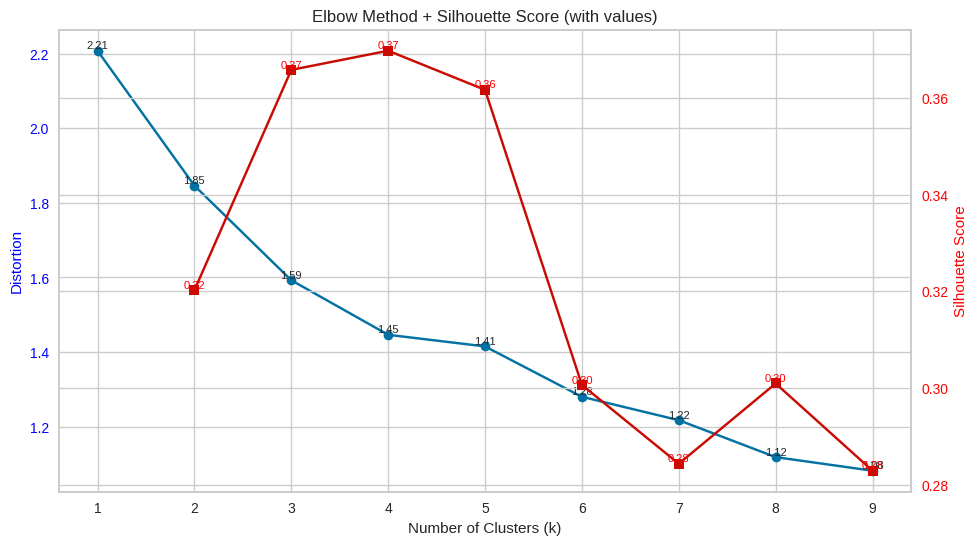

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import numpy as np

clusters = range(1, 10)

meanDistortions = []
sil_scores = []

# =========================
# Compute values
# =========================
for k in clusters:

    model = KMeans(n_clusters=k, random_state=42)
    model.fit(subset_scaled_df)

    # Elbow (distortion)
    distortion = np.sum(
        np.min(
            cdist(subset_scaled_df, model.cluster_centers_, 'euclidean'),
            axis=1
        )
    ) / subset_scaled_df.shape[0]

    meanDistortions.append(distortion)

    # print values (as requested)
    print(f"Number of Clusters: {k}, Distortion: {distortion}")

    # Silhouette
    if k > 1:
        score = silhouette_score(subset_scaled_df, model.labels_)
        sil_scores.append(score)

        print(f"Silhouette Score for k={k}: {score}")


# =========================
# Combined Plot (single figure)
# =========================

fig, ax1 = plt.subplots(figsize=(11, 6))

# ----- Elbow curve -----
ax1.plot(list(clusters), meanDistortions, 'bo-', label='Distortion')

# Annotate distortion values
for k, val in zip(clusters, meanDistortions):
    ax1.text(k, val, f"{val:.2f}", fontsize=8, ha='center', va='bottom')

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Distortion', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# ----- Silhouette (second axis) -----
ax2 = ax1.twinx()

ax2.plot(range(2, 10), sil_scores, 'rs-', label='Silhouette Score')

# Annotate silhouette values
for k, val in zip(range(2, 10), sil_scores):
    ax2.text(k, val, f"{val:.2f}", fontsize=8, ha='center', va='bottom', color='red')

ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Elbow Method + Silhouette Score (with values)')

plt.show()

As the number of clusters (k) increases, the distortion decreases steadily, meaning the data points are fitting more closely to their cluster centers. This is expected because adding more clusters always reduces within-cluster distance.

However, the Silhouette Score behaves differently. It measures how well-separated and compact the clusters are:

It increases from k = 2 (0.32) to a peak around k = 4 (0.37).
After k = 4, the score starts to decline or fluctuate, indicating weaker cluster structure despite lower distortion.

**Key interpretation:**

Elbow Method (distortion): suggests improvement continues as k increases, but with diminishing returns.

Silhouette Score: indicates the best balance of cohesion and separation is around k = 4.

**Conclusion:**

Even though distortion keeps decreasing, k = 4 is a strong candidate for the optimal number of clusters, because it gives the highest-quality and most well-separated clustering structure.

**Silhouette score for 4 is higher than that for 3. So, we will choose 4 as value of k.**

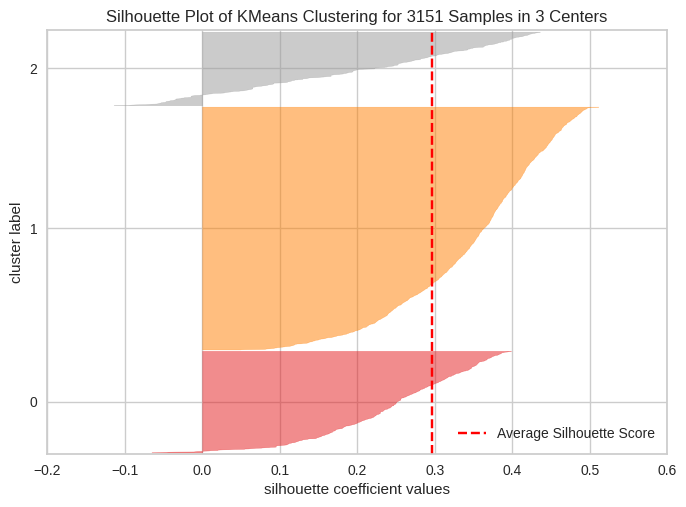

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 3151 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

**A visual graph showing how well-separated and well-formed the 3 clusters are.**

- High silhouette values (close to 1): points are well clustered
- Around 0: overlapping clusters
- Negative values: incorrect clustering

In short: this helps you check if k = 3 produces meaningful and well-separated clusters.

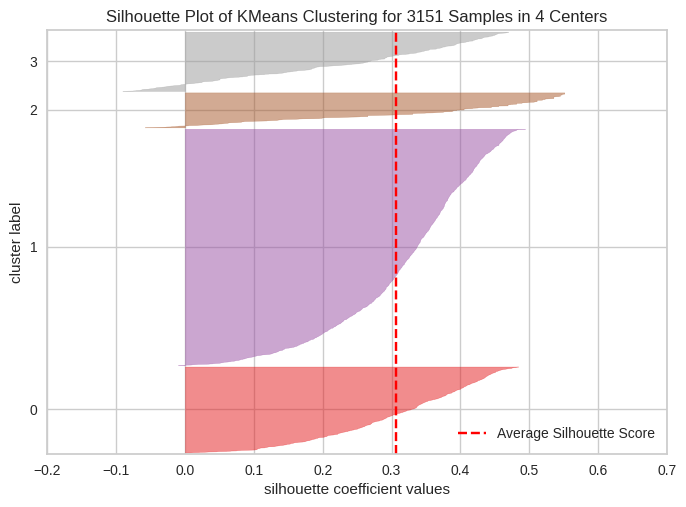

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 3151 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

Checking whether 4 clusters gives a better or worse separation compared to 3 clusters.

- If the bars are mostly high and uniform, k=4 is a good choice.
- If many values are low or negative, clustering quality is weak.
- Compare this result with k=3 to decide which number of clusters is better.

**In short:**

This plot evaluates whether increasing the number of clusters to 4 improves cluster quality using silhouette scores.

In [ ]:
# let's take 4 as number of clusters
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=4, random_state=0)

In [ ]:
# adding kmeans cluster labels to the original and scaled dataframes

df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

## Cluster Profiling

In [ ]:
cluster_profile = df.groupby("K_means_segments").mean(numeric_only=True)

In [ ]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Sale_Price"].count().values
)

In [ ]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Listing_Price,Sale_Price,Discount,Rating,Reviews,count_in_each_segments
K_means_segments,,,,,,
0,9725.996255,8331.101124,7.715356,0.255805,11.898876,267
1,6629.654600,6275.108597,0.935143,3.800302,39.104072,663
2,6801.853945,3688.562955,45.433688,3.390319,50.137101,1787
3,15711.592166,13540.774194,9.032258,3.932719,30.647465,434


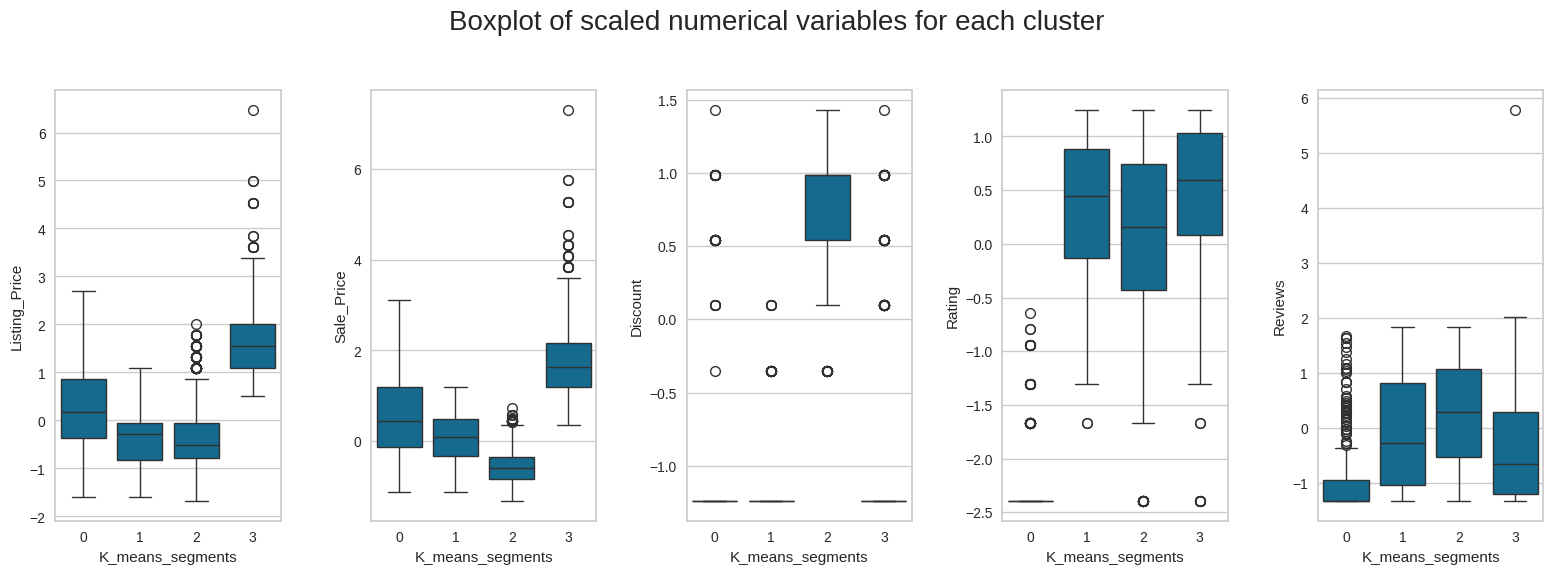

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

- Shows relative differences between clusters
- Used for clustering interpretation and model behavior analysis
- Best for understanding how clusters differ statistically

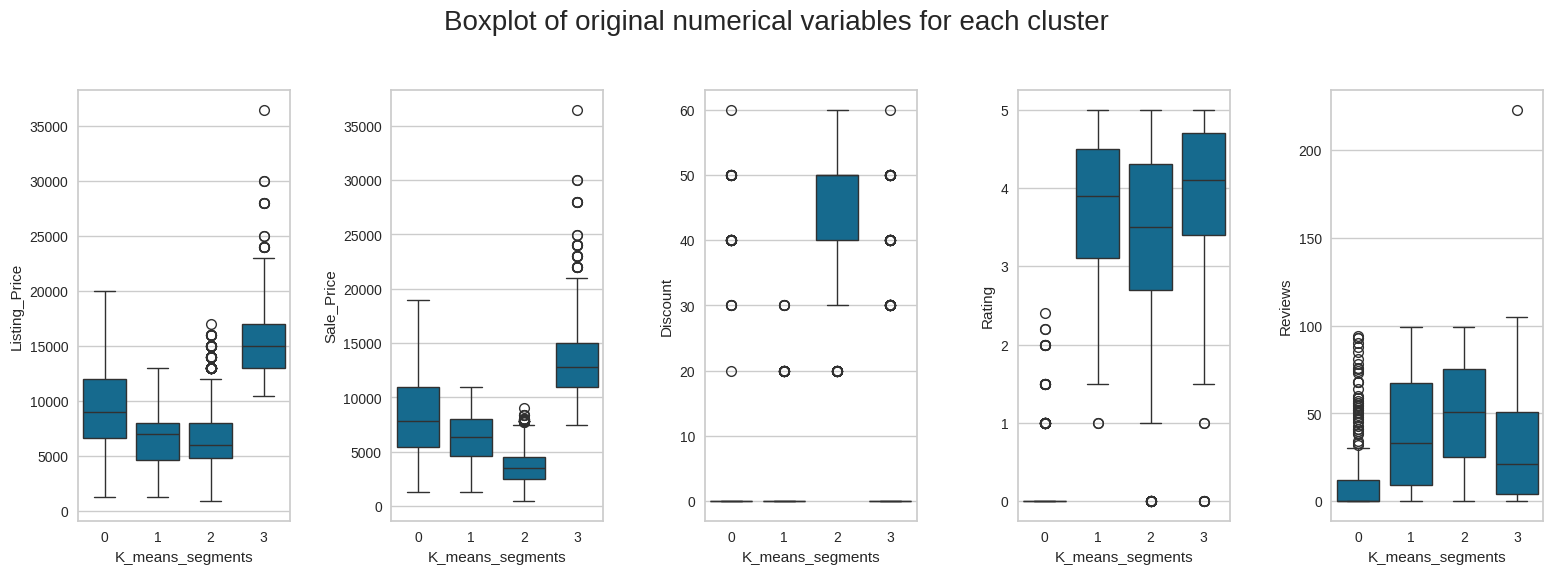

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_col[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

- Shows real-world meaning of clusters
- Useful for answering:
-  “Which cluster has higher weight?”
-  “Which cluster has higher price?”

**Cluster 0:** Mid-price, low engagement products

This cluster contains mid-range priced products, with an average listing price of approximately 9,726 and a sale price of 8,331.

Products in this cluster receive a moderate discount (~7.7%), indicating limited promotional activity.

However, the most notable characteristic is the very low rating (0.26) and low number of reviews (12), suggesting either missing ratings or very low customer engagement.

Overall, this cluster likely represents products that are less popular or poorly reviewed, rather than premium products.

**Cluster 1:** Low-price, stable rating products

This cluster contains the lowest-priced products, with an average listing price of approximately 6,630 and a sale price of 6,275.

Products in this cluster receive almost no discount (~0.9%), indicating stable pricing.

Despite low pricing, the products show a relatively good rating (~3.8), with around 39 reviews on average, suggesting consistent customer satisfaction.

This cluster represents budget-friendly products with stable performance and moderate customer feedback.

**Cluster 2:** Highly discounted, high-engagement products

This cluster has a listing price of approximately 6,802, but a much lower sale price of 3,689, indicating a very high discount (~45%).

It also has the highest number of reviews (~50) among all clusters, showing strong customer engagement.

Ratings are moderate (~3.39), suggesting acceptable but not exceptional satisfaction.

This cluster clearly represents heavily discounted promotional products that attract high customer interaction.

**Cluster 3:** Premium, high-rated products

This cluster contains the highest-priced products, with an average listing price of approximately 15,712 and a sale price of 13,541.

Products receive a moderate discount (~9%), but still maintain premium pricing.

This cluster also has the highest rating (3.93), indicating strong customer satisfaction, with a moderate number of reviews (~31).

Overall, this cluster represents premium products with good customer perception and relatively stable demand.

**Let's compare Cluster vs Brand**

In [ ]:
pd.crosstab(df.K_means_segments, df.Brand).style.highlight_max(
    color="lightgreen", axis=0
)

Brand,Adidas Adidas ORIGINALS,Adidas CORE / NEO,Adidas ORIGINALS,Adidas SPORT PERFORMANCE,Nike
K_means_segments,,,,,
0,0,18,53,23,173
1,0,227,166,101,169
2,1,866,564,356,0
3,0,0,123,126,185


The clustering results show a clear difference between the two brands.

Adidas products are spread across more clusters, indicating a broader and more diversified product strategy across CORE, ORIGINALS, and PERFORMANCE lines. Nike products are more concentrated in fewer clusters, suggesting a more focused product strategy.

Overall, Adidas appears to cover a wider range of market segments, while Nike is more selective and concentrated in specific product groups.

**Observations**

- Adidas gives more discounts on their products, while Nike barely gives any.
- Nearly one-third of Nike products are premium in nature.

## Business Recommendations

**Cluster 0:** Mid-price products with very low ratings and engagement → focus on improving product quality, visibility, or repositioning.

**Cluster 1:** Low-price, stable products with good ratings → maintain pricing and promote as value-for-money options.

**Cluster 2:** High-discount products with highest reviews → ideal for promotional and seasonal sales campaigns.

**Cluster 3:** Premium, high-priced products with strong ratings → position as flagship/premium offerings with brand-focused marketing.